In [48]:
import pandas as pd
import numpy as np
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [22]:
dataframe = pd.read_csv("../data/Telco_customer_churn copy.csv")
df = dataframe.copy()

In [23]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [24]:
print(df.isnull().sum())

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [25]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [26]:
print(df["Total Charges"].isnull().sum())

11


In [27]:
df.loc[
    df["Total Charges"].isnull() & (df["Tenure Months"] == 0),
    "Total Charges"
] = 0

In [28]:
print(df["Total Charges"].isnull().sum())

0


In [29]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Churn Label"]
)

print("Training:", train_df.shape)
print("Testing:", test_df.shape)

Training: (5634, 33)
Testing: (1409, 33)


In [30]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [31]:
print(train_df[numeric_features].head())

      Tenure Months  Monthly Charges  Total Charges  CLTV
4626             35            49.20        1701.65  2782
4192             15            75.10        1151.55  4634
5457             13            40.55         590.35  2898
4717             26            73.50        1905.70  3596
4673              1            44.55          44.55  3408


In [32]:
X_train = train_df[numeric_features].copy()
X_test = test_df[numeric_features].copy()

In [33]:
print(X_train.shape)
print(X_test.shape)

(5634, 4)
(1409, 4)


In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
scaler.fit_transform(X_train)

array([[ 0.10237124, -0.52197565, -0.2622572 , -1.37223596],
       [-0.71174346,  0.33747781, -0.50363479,  0.19448619],
       [-0.79315493, -0.80901319, -0.74988292, -1.27410434],
       ...,
       [-0.30468611,  1.25666162,  0.15834357,  0.47788355],
       [-0.34539184, -1.47766135, -0.79707463, -1.12775286],
       [-1.07809507, -1.46936546, -0.96096216, -0.96279022]],
      shape=(5634, 4))

In [36]:
scaler.transform(X_test)

array([[ 1.60848343,  1.62997635,  2.70682752,  0.37044634],
       [-0.9966836 ,  1.16872526, -0.61026041,  0.63692446],
       [ 0.34660565,  0.44532428,  0.40011607, -1.27748818],
       ...,
       [-1.11880081, -1.46936546, -0.96787308,  1.00914787],
       [ 0.95719167, -1.50088982, -0.54736007,  0.36114076],
       [ 1.60848343,  0.18317439,  1.2577283 ,  0.04982664]],
      shape=(1409, 4))

In [37]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

print(X_train_scaled[:5])

(5634, 4)
(1409, 4)
[[ 0.10237124 -0.52197565 -0.2622572  -1.37223596]
 [-0.71174346  0.33747781 -0.50363479  0.19448619]
 [-0.79315493 -0.80901319 -0.74988292 -1.27410434]
 [-0.26398038  0.28438416 -0.17272239 -0.68362266]
 [-1.28162375 -0.67627907 -0.98937372 -0.84266357]]


## PART B1:

In [38]:

# 1. PCA with all possible components
pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(X_train_scaled)

# 2. Explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained variance ratio:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

# 3. Display cumulative variance
for i, variance in enumerate(cumulative_variance, start=1):
    print(f"{i} components: {variance:.4f}")

# 4. Choose number of components
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 5. KMeans on PCA data
km_pca = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=42
)

pca_labels = km_pca.fit_predict(X_train_pca)

# 6. Silhouette
pca_silhouette = silhouette_score(
    X_train_pca,
    pca_labels
)

print("\nOriginal shape:", X_train_scaled.shape)
print("PCA shape:", X_train_pca.shape)
print("PCA + KMeans silhouette:", pca_silhouette)

Explained variance ratio:
[0.59405875 0.23751959 0.15376528 0.01465638]

Cumulative explained variance:
[0.59405875 0.83157834 0.98534362 1.        ]
1 components: 0.5941
2 components: 0.8316
3 components: 0.9853
4 components: 1.0000

Original shape: (5634, 4)
PCA shape: (5634, 3)
PCA + KMeans silhouette: 0.3435448454204931


Three principal components provide a substantial dimensionality reduction while retaining approximately 98.53% of the variance in the original four numeric features.

## PART B2

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 9):

    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = km.fit_predict(X_train_scaled)

    score = silhouette_score(
        X_train_scaled,
        labels
    )

    scores[k] = score

print("Silhouette scores:")

for k, score in scores.items():
    print(f"k={k}: {score:.4f}")

best_k = max(scores, key=scores.get)

print("\nBest k by silhouette:", best_k)
print("Best silhouette score:", scores[best_k])

Silhouette scores:
k=2: 0.3936
k=3: 0.3352
k=4: 0.3387
k=5: 0.3601
k=6: 0.3524
k=7: 0.3467
k=8: 0.3217

Best k by silhouette: 2
Best silhouette score: 0.3935712382850272


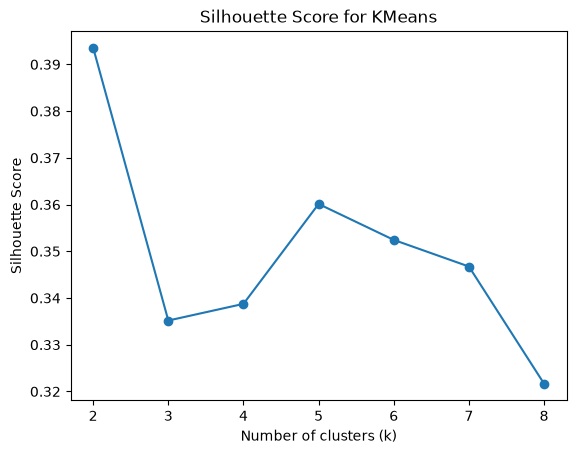

In [40]:
import matplotlib.pyplot as plt

plt.plot(
    list(scores.keys()),
    list(scores.values()),
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for KMeans")
plt.xticks(range(2, 9))
plt.show()

In [41]:
km = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=42
)

labels = km.fit_predict(X_train_scaled)

In [ ]:
cluster_profile = X_train.copy()
cluster_profile["Cluster"] = labels

print(cluster_profile.groupby("Cluster").mean())

         Tenure Months  Monthly Charges  Total Charges         CLTV
Cluster                                                            
0            19.541879        53.329743     899.912242  4054.798769
1            57.982604        87.781840    5056.130496  5092.208751


In [51]:
mean_cluster_proffile = cluster_profile.groupby("Cluster").mean()

In [52]:
mean_cluster_proffile.to_csv("Cluster_profile.csv")

In [46]:
cluster_churn = train_df[["Churn Label"]].copy()
cluster_churn["Cluster"] = labels

cluster_churn["Churn"] = cluster_churn["Churn Label"].map({
    "Yes": 1,
    "No": 0
})

print(cluster_churn.groupby("Cluster")["Churn"].mean())

Cluster
0    0.317634
1    0.162362
Name: Churn, dtype: float64
